In [ ]:
# this file plots all the absolute coefficients that were saved from the ridge regression
# ridge regression was run for predicting case vs control 

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

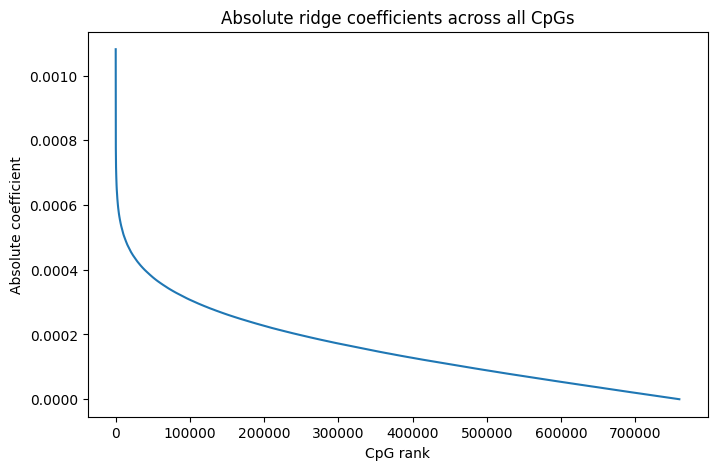

In [20]:
coef_df = pd.read_csv("ridge_top_features_all.csv")
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

plt.figure(figsize=(8,5))
plt.plot(coef_df.index + 1, coef_df["abs_coef"])
plt.xlabel("CpG rank")
plt.ylabel("Absolute coefficient")
plt.title("Absolute ridge coefficients across all CpGs")
plt.show()

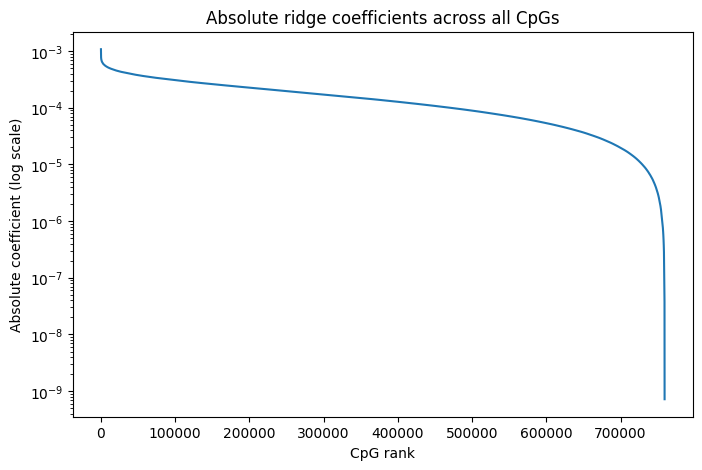

In [21]:
plt.figure(figsize=(8,5))
plt.plot(coef_df.index + 1, coef_df["abs_coef"])
plt.yscale("log")
plt.xlabel("CpG rank")
plt.ylabel("Absolute coefficient (log scale)")
plt.title("Absolute ridge coefficients across all CpGs")
plt.show()

In [22]:
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [23]:
from kneed import KneeLocator
import numpy as np

# sorted absolute coefficients (descending)
y = np.sort(coef_df["abs_coef"].values)[::-1]
x = np.arange(1, len(y) + 1)

# find knee
kneedle = KneeLocator(
    x, y,
    curve="convex",        # shape of your curve
    direction="decreasing" # because it slopes down
)

knee_point = kneedle.knee
print("Knee at CpG rank:", knee_point)

Knee at CpG rank: 978


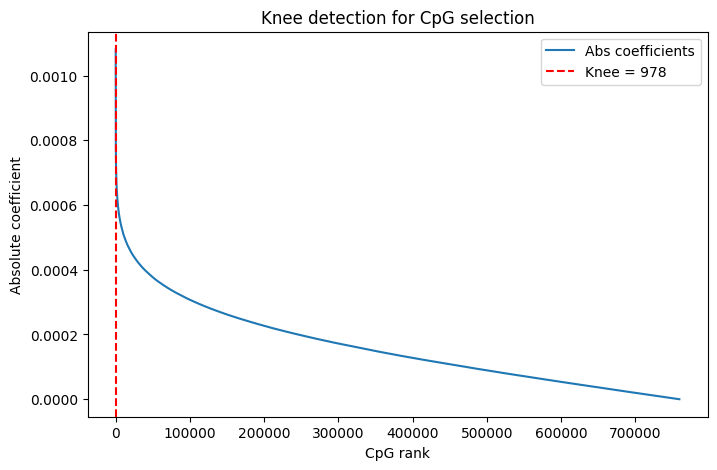

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(x, y, label="Abs coefficients")
plt.axvline(knee_point, color='red', linestyle='--', label=f"Knee = {knee_point}")
plt.xlabel("CpG rank")
plt.ylabel("Absolute coefficient")
plt.title("Knee detection for CpG selection")
plt.legend()
plt.show()

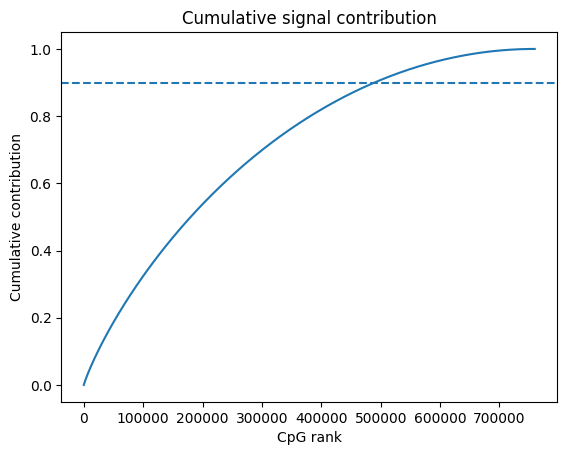

In [25]:
cumulative = np.cumsum(y) / np.sum(y)

plt.plot(x, cumulative)
plt.axhline(0.9, linestyle="--")
plt.xlabel("CpG rank")
plt.ylabel("Cumulative contribution")
plt.title("Cumulative signal contribution")
plt.show()

### extacting top 978 cpgs

In [33]:
import scanpy as sc
import numpy as np
import pandas as pd

adata = sc.read_h5ad("M_smartsva_corrected_with_SH_annot_filtered.h5ad")

X = adata.X
y = adata.obs["endo"].astype(int).to_numpy()

print("adata shape:", adata.shape)
print("obs columns:", adata.obs.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 CpGs:", adata.var_names[:5])

adata shape: (984, 759345)
obs columns: ['sample-id', 'endo', 'endo-stage', 'endo-stage-grouped', 'cycle-phase', 'cycle-phase-source']
X shape: (984, 759345)
y shape: (984,)
First 5 CpGs: Index(['cg21870274', 'cg09499020', 'cg16535257', 'cg06325811', 'cg08258224'], dtype='object', name='cpg')


In [34]:
top_cpgs_in_data = [cpg for cpg in top_cpgs if cpg in adata.var_names]

print("CpGs found in data:", len(top_cpgs_in_data))
print("CpGs missing from data:", len(top_cpgs) - len(top_cpgs_in_data))

top_idx = [i for i, cpg in enumerate(adata.var_names) if cpg in top_cpgs_in_data]

print("Number of selected column indices:", len(top_idx))

X_top978 = X[:, top_idx]
cpg_names_top978 = [adata.var_names[i] for i in top_idx]
y_top978 = y.copy()

print("Original X shape:", X.shape)
print("Subsetted X_top978 shape:", X_top978.shape)
print("Number of CpGs in subset:", len(cpg_names_top978))

CpGs found in data: 978
CpGs missing from data: 0
Number of selected column indices: 978
Original X shape: (984, 759345)
Subsetted X_top978 shape: (984, 978)
Number of CpGs in subset: 978


In [38]:
from sklearn.model_selection import train_test_split

X_train_top978, X_test_top978, y_train_top978, y_test_top978 = train_test_split(
    X_top978,
    y_top978,
    test_size=0.2,
    stratify=y_top978,
    random_state=42
)

print("Train shape:", X_train_top978.shape)
print("Test shape:", X_test_top978.shape)

Train shape: (787, 978)
Test shape: (197, 978)


In [40]:
from scipy import sparse
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

is_sparse = sparse.issparse(X_train_top978)
with_mean = not is_sparse

Cs = np.logspace(-6, 2, 25)
all_results_top978 = []

for C_val in tqdm(Cs, desc="Ridge (top 978 CpGs)"):

    ridge_pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=with_mean)),
        ("logreg", LogisticRegression(
            penalty="l2",
            C=C_val,
            solver="lbfgs" if not is_sparse else "saga",
            max_iter=5000,
            tol=1e-3
        ))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_scores = cross_val_score(
        ridge_pipe,
        X_train_top978,
        y_train_top978,
        cv=cv,
        scoring="roc_auc",
        n_jobs=4
    )

    ridge_pipe.fit(X_train_top978, y_train_top978)

    test_prob = ridge_pipe.predict_proba(X_test_top978)[:, 1]
    test_auc = roc_auc_score(y_test_top978, test_prob)

    all_results_top978.append({
        "C": C_val,
        "cv_auc_mean": cv_scores.mean(),
        "cv_auc_std": cv_scores.std(),
        "test_auc": test_auc,
        "model": ridge_pipe
    })

Ridge (top 978 CpGs): 100%|██████████| 25/25 [00:16<00:00,  1.51it/s]


In [41]:
results_df_top978 = pd.DataFrame(all_results_top978).drop(columns="model")

best_idx = results_df_top978["cv_auc_mean"].idxmax()
best_C_top978 = results_df_top978.loc[best_idx, "C"]

best_model_top978 = all_results_top978[best_idx]["model"]
best_test_auc_top978 = all_results_top978[best_idx]["test_auc"]

print("Best C:", best_C_top978)
print("Best CV AUC:", results_df_top978.loc[best_idx, "cv_auc_mean"])
print("Test AUC:", best_test_auc_top978)

Best C: 0.1
Best CV AUC: 0.9999649859943978
Test AUC: 0.8379755434782609


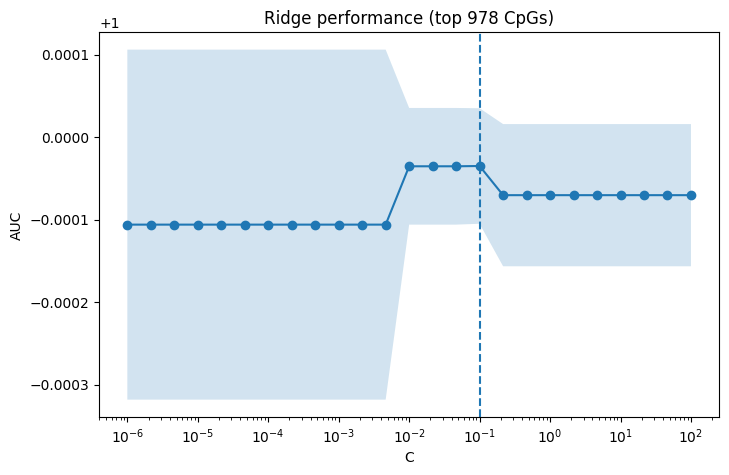

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.semilogx(results_df_top978["C"], results_df_top978["cv_auc_mean"], marker="o")
plt.fill_between(
    results_df_top978["C"],
    results_df_top978["cv_auc_mean"] - results_df_top978["cv_auc_std"],
    results_df_top978["cv_auc_mean"] + results_df_top978["cv_auc_std"],
    alpha=0.2
)
plt.axvline(best_C_top978, linestyle="--")
plt.xlabel("C")
plt.ylabel("AUC")
plt.title("Ridge performance (top 978 CpGs)")
plt.show()

In [44]:
logreg_top978 = best_model_top978.named_steps["logreg"]
coef_top978 = logreg_top978.coef_.ravel()

coef_df_top978 = pd.DataFrame({
    "cpg": list(cpg_names_top978),
    "coef": coef_top978,
    "abs_coef": np.abs(coef_top978)
}).sort_values("abs_coef", ascending=False)

coef_df_top978.to_csv("ridge_top_features_top978.csv", index=False)
results_df_top978.to_csv("ridge_results_top978.csv", index=False)

print("Saved: ridge_top_features_top978.csv")
print("Saved: ridge_results_top978.csv")

Saved: ridge_top_features_top978.csv
Saved: ridge_results_top978.csv


In [45]:
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import numpy as np

In [46]:
y_prob_top978 = best_model_top978.predict_proba(X_test_top978)[:, 1]
y_pred_top978 = (y_prob_top978 >= 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_test_top978, y_prob_top978)
roc_auc = auc(fpr, tpr)

precision_curve, recall_curve, _ = precision_recall_curve(y_test_top978, y_prob_top978)
pr_auc = average_precision_score(y_test_top978, y_prob_top978)

accuracy = accuracy_score(y_test_top978, y_pred_top978)
precision = precision_score(y_test_top978, y_pred_top978, zero_division=0)
recall = recall_score(y_test_top978, y_pred_top978, zero_division=0)
f1 = f1_score(y_test_top978, y_pred_top978, zero_division=0)

tn, fp, fn, tp = confusion_matrix(y_test_top978, y_pred_top978).ravel()

print(f"AUROC: {roc_auc:.3f}")
print(f"AUPRC: {pr_auc:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

AUROC: 0.838
AUPRC: 0.902
Accuracy: 0.751
Precision: 0.772
Recall: 0.875
F1-score: 0.821
TN: 36, FP: 33, FN: 16, TP: 112


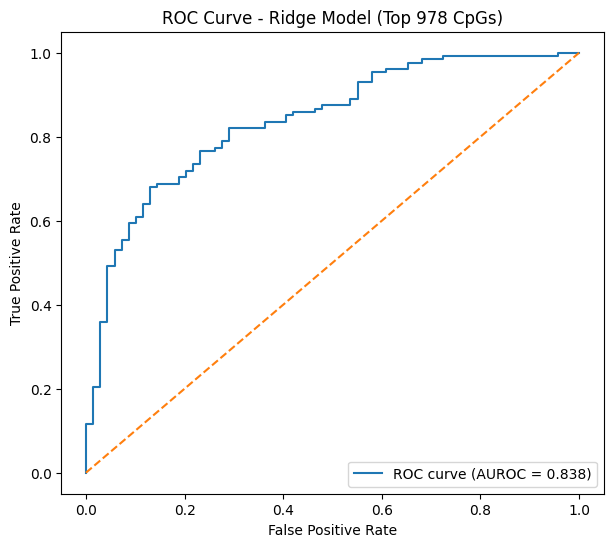

In [47]:
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUROC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Ridge Model (Top 978 CpGs)")
plt.legend(loc="lower right")
plt.show()

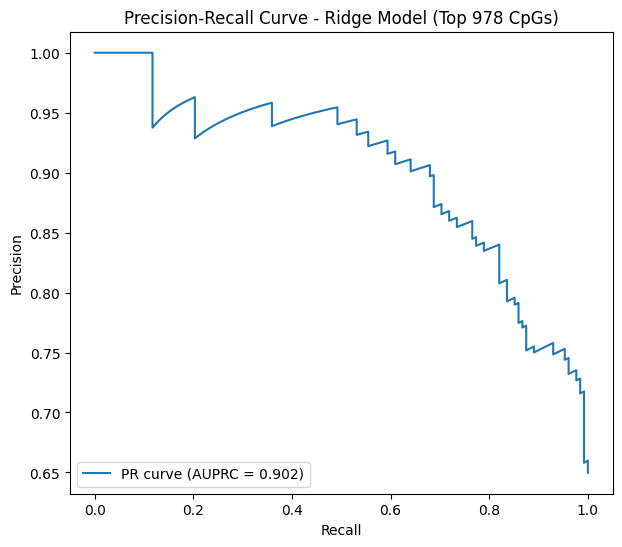

In [48]:
plt.figure(figsize=(7, 6))
plt.plot(recall_curve, precision_curve, label=f"PR curve (AUPRC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Ridge Model (Top 978 CpGs)")
plt.legend(loc="lower left")
plt.show()

In [49]:
metrics_top978 = pd.DataFrame({
    "metric": ["AUROC", "AUPRC", "Accuracy", "Precision", "Recall", "F1"],
    "value": [roc_auc, pr_auc, accuracy, precision, recall, f1]
})

metrics_top978

,metric,value
0,AUROC,0.837976
1,AUPRC,0.902294
2,Accuracy,0.751269
3,Precision,0.772414
4,Recall,0.875000
5,F1,0.820513


In [50]:
metrics_top978.to_csv("ridge_top978_test_metrics.csv", index=False)
print("Saved: ridge_top978_test_metrics.csv")

Saved: ridge_top978_test_metrics.csv


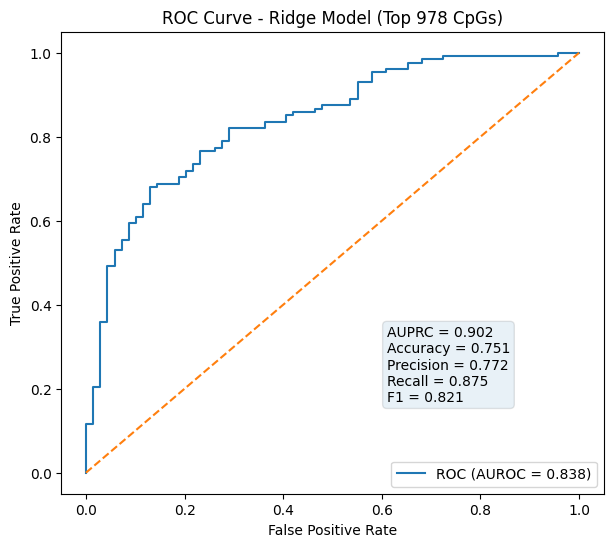

In [51]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, label=f"ROC (AUROC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--")

metrics_text = (
    f"AUPRC = {pr_auc:.3f}\n"
    f"Accuracy = {accuracy:.3f}\n"
    f"Precision = {precision:.3f}\n"
    f"Recall = {recall:.3f}\n"
    f"F1 = {f1:.3f}"
)

ax.text(
    0.60, 0.20, metrics_text,
    transform=ax.transAxes,
    bbox=dict(boxstyle="round", alpha=0.1)
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Ridge Model (Top 978 CpGs)")
ax.legend(loc="lower right")
plt.show()